In [2]:
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import itertools


In [3]:
curve_df = pd.read_hdf('./data/data.h5', key='curve_data')
sample_info = pd.read_hdf('./data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('./data/data.h5', key='igi_gene_call')
groundtruth_df = pd.read_csv('./data/groundtruth_df.csv')
groundtruth_df.loc[:,'groundtruth_label'] = groundtruth_df.groundtruth.replace({-1:0, 1:1})
groundtruth_df.loc[:,'encoded_igi_call'] = groundtruth_df.igi_call.replace({'Negative':0, 'Positive':1})
fusion_val_pred = pd.read_csv('./data/fusion_pred_df.csv')
fusion_test_pred = pd.read_csv('./data/fusion_tes_pred_df.csv')

In [4]:
groundtruth_df.head()

,curve_idx,target,sample_type,sample_id,igi_call,cycle_no,Fn,rn,groundtruth,split,groundtruth_label,encoded_igi_call
0,24933,S gene,Negative Control (qPCR),S252611,Negative,1,195418.72,195418.718750,-1,train,0,0
1,24933,S gene,Negative Control (qPCR),S252611,Negative,2,195288.33,195288.328125,-1,train,0,0
2,24933,S gene,Negative Control (qPCR),S252611,Negative,3,194651.67,194651.671875,-1,train,0,0
3,24933,S gene,Negative Control (qPCR),S252611,Negative,4,194355.02,194355.015625,-1,train,0,0
4,24933,S gene,Negative Control (qPCR),S252611,Negative,5,194165.97,194165.968750,-1,train,0,0


In [5]:
join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))


In [6]:
val_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'val', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(pd.concat([fusion_test_pred, fusion_val_pred], axis=0), how='inner', on = 'curve_idx'))
test_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(pd.concat([fusion_test_pred, fusion_val_pred], axis=0), how='inner', on = 'curve_idx'))

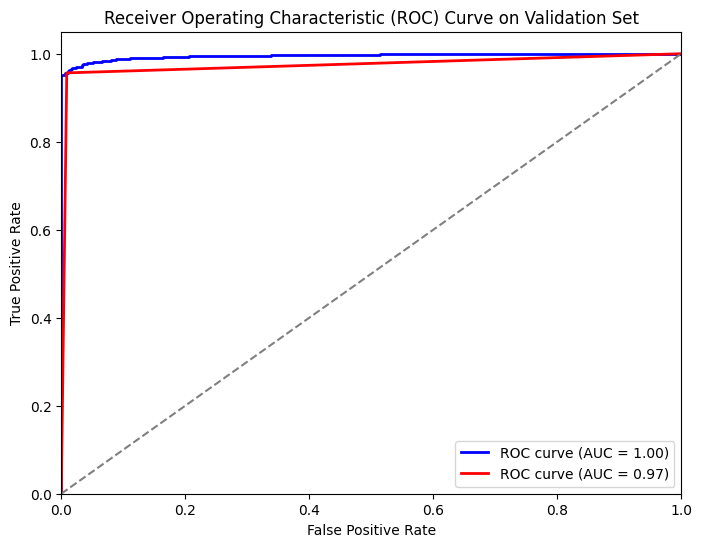

In [7]:
val_fusion_auc = roc_auc_score(val_pred_df.groundtruth_label, val_pred_df.outputs)
val_fusion_fpr, val_fusion_tpr, val_fusion_thresholds = roc_curve(val_pred_df.groundtruth_label, val_pred_df.outputs)

val_igi_auc = roc_auc_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
val_igi_fpr, val_igi_tpr, val_igi_thresholds = roc_curve(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(val_fusion_fpr, val_fusion_tpr, color='blue', lw=2, label='ROC curve (AUC = {:.2f})'.format(val_fusion_auc))
plt.plot(val_igi_fpr, val_igi_tpr, color='red', lw=2, label='ROC curve (AUC = {:.2f})'.format(val_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Set')
plt.legend(loc='lower right')
plt.show()


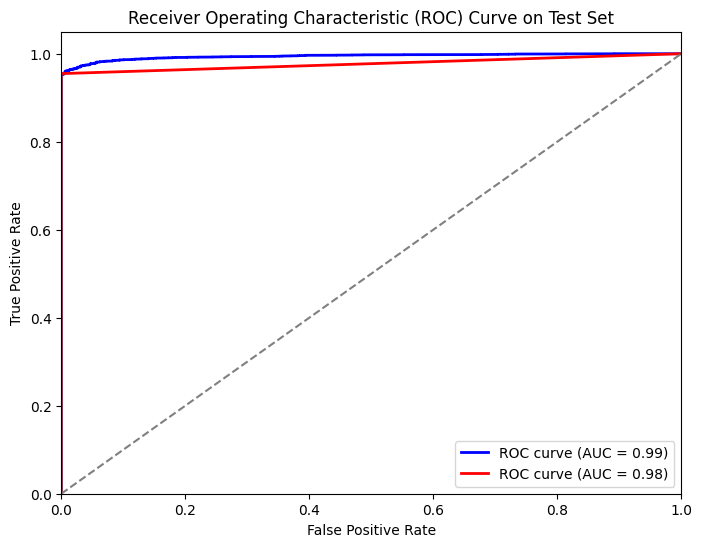

In [8]:
test_fusion_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
test_fusion_fpr, test_fusion_tpr, test_fusion_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fusion_fpr, test_fusion_tpr, color='blue', lw=2, label='ROC curve (AUC = {:.2f})'.format(test_fusion_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


IGI precision score: 0.9990002499375156
IGI recall score: 0.9564489112227805
Threshold to match IGI precision score: 0.9156565656565656


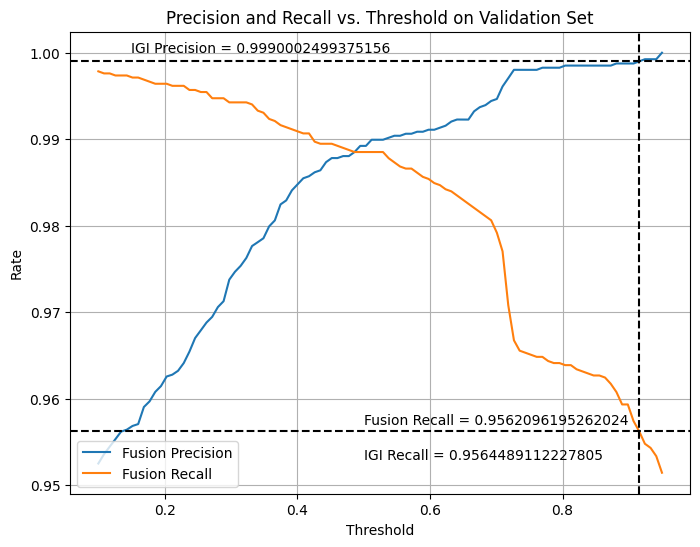

In [185]:
igi_recall = recall_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
igi_precision = precision_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
# igi_tp = sum((val_pred_df.groundtruth_label == val_pred_df.encoded_igi_call) & (val_pred_df.encoded_igi_call == 1))

# print('IGI true positive:', igi_tp)
print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 0.95, 100)
tprs, fusion_precisions, fusion_recalls = [], [], []
for thres in thresholds:
    fusion_pred = 1*(val_pred_df.outputs >= thres)
    tprs.append(sum((val_pred_df.groundtruth_label == 1) & (val_pred_df.groundtruth_label == fusion_pred)))
    fusion_precisions.append(precision_score(val_pred_df.groundtruth_label, fusion_pred))
    fusion_recalls.append(recall_score(val_pred_df.groundtruth_label, fusion_pred))

threshold_idx = fusion_precisions.index(0.999)
matched_thres = thresholds[threshold_idx]
print('Threshold to match IGI precision score:', matched_thres)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, fusion_precisions, label='Fusion Precision')
plt.plot(thresholds, fusion_recalls, label='Fusion Recall')
plt.axhline(igi_precision, color = 'black', linestyle='--')
plt.annotate(f'IGI Precision = {igi_precision}', xy=(0.1, 0.999), xytext=(0.15, 1))
plt.axvline(thresholds[threshold_idx], color = 'black', linestyle='--')
plt.axhline(fusion_recalls[threshold_idx], color = 'black', linestyle='--')
plt.annotate(f'Fusion Recall = {fusion_recalls[threshold_idx]}', xy=(0.1, 0.956), xytext=(0.5, 0.957))
plt.annotate(f'IGI Recall = {igi_recall}', xy=(0.1, 0.95), xytext=(0.5, 0.953))
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Precision and Recall vs. Threshold on Validation Set")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


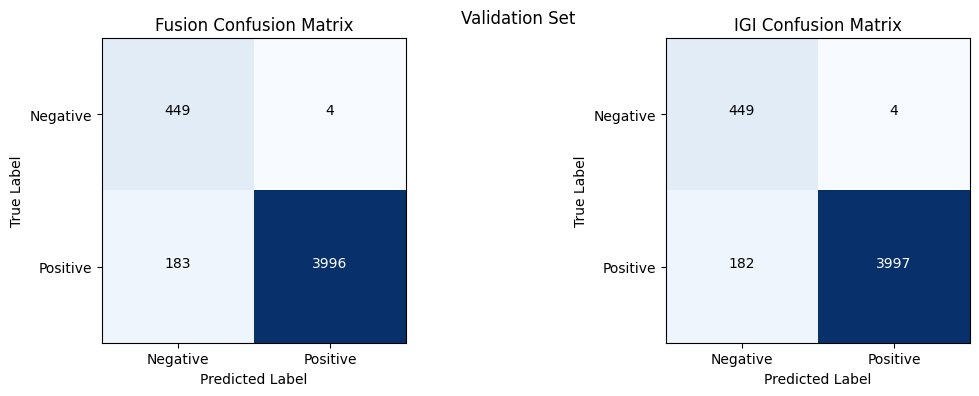

In [186]:
matched_preds = 1*(val_pred_df.outputs >= matched_thres)
# Calculate the confusion matrix
cm1 = confusion_matrix(val_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Fusion Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.tight_layout()
fig.suptitle('Validation Set')
plt.show()


In [187]:
print('Fusion Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, round(val_pred_df.fusion_matched_pred)))
print('IGI Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call))

Fusion Model confusion matrix
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       453
           1       1.00      0.96      0.98      4179

    accuracy                           0.96      4632
   macro avg       0.85      0.97      0.90      4632
weighted avg       0.97      0.96      0.96      4632

IGI Model confusion matrix
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       453
           1       1.00      0.96      0.98      4179

    accuracy                           0.96      4632
   macro avg       0.86      0.97      0.90      4632
weighted avg       0.97      0.96      0.96      4632



In [188]:
val_pred_df.loc[:,['fusion_matched_pred']] = matched_preds
diff_df = val_pred_df.loc[val_pred_df.encoded_igi_call != val_pred_df.fusion_matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 91


,curve_idx,groundtruth_label,encoded_igi_call,outputs,fusion_matched_pred
74,13349,0,0,0.947970,1
289,103252,1,0,0.971636,1
438,45626,1,1,0.900606,0
513,7304,1,1,0.078462,0
515,7108,1,1,0.834284,0


29135
86000
86384


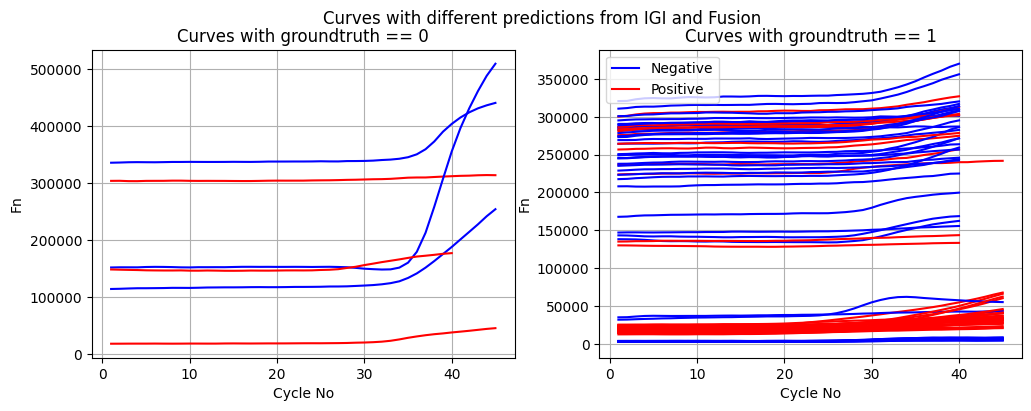

In [189]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['fusion_matched_pred'].values == 0:
            print(idx)
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['fusion_matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
axes[1].legend()
fig.suptitle('Curves with different predictions from IGI and Fusion')
plt.show()

/tmp/ipykernel_2033225/2488595735.py:28: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, label='Fusion Scores')


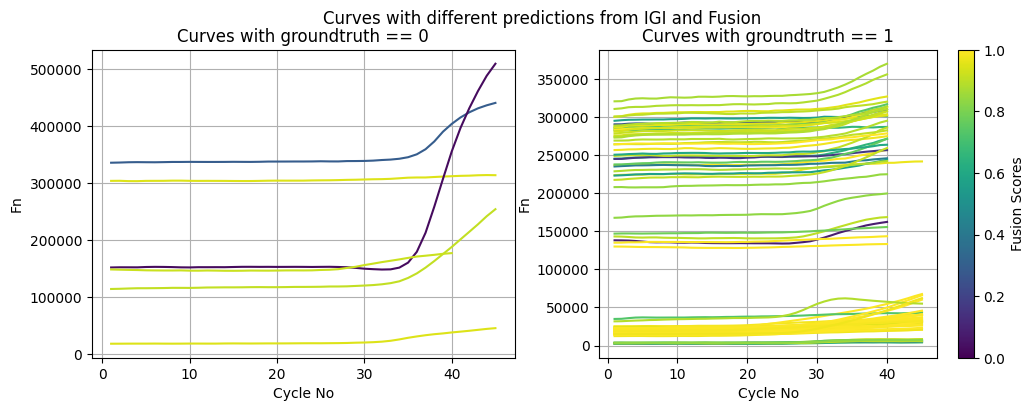

In [174]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1, label = 'Fusion predicts negative')
    else:
        axes[1].plot(x,y, color = color1, label = 'Fusion predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Fusion Scores')
fig.suptitle('Curves with different predictions from IGI and Fusion')
plt.show()

In [175]:
val_sample_df = (val_pred_df[['curve_idx','encoded_igi_call','fusion_matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

val_sample_df.loc[:,'sample_type'] = val_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
val_sample_pred = (val_sample_df
 .groupby('sample_id')[['fusion_matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in fusion prediction is: ', (sum(val_sample_pred.fusion_matched_pred.isin([0,1]))/val_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(val_sample_pred.encoded_igi_call.isin([0,1]))/val_sample_pred.shape[0]))

Agreement rate between genes in fusion prediction is:  0.9767441860465116
Agreement rate between genes in IGI prediction is:  0.986046511627907


IGI precision score: 1.0
IGI recall score: 0.9547910662824207
Threshold to match IGI precision score: 0.9454545454545454


/home/alpaca/anaconda3/envs/huong/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


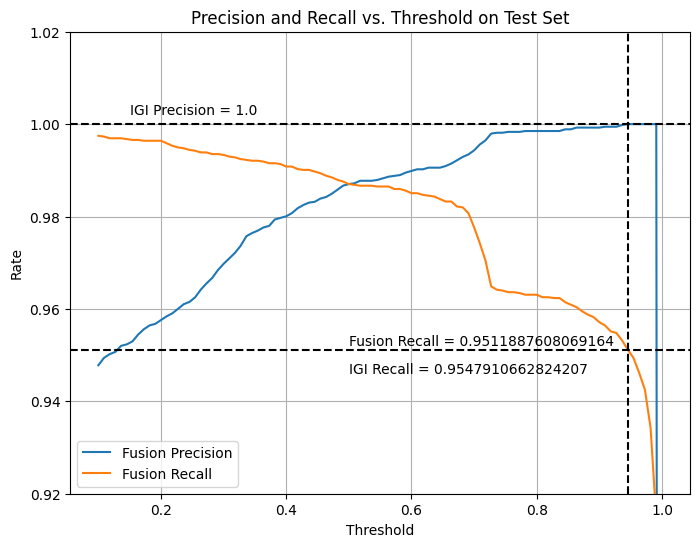

In [176]:
igi_recall = recall_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
igi_precision = precision_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 100)
fusion_precisions, fusion_recalls = [], []
for thres in thresholds:
    fusion_pred = 1*(test_pred_df.outputs >= thres)
    fusion_precisions.append(precision_score(test_pred_df.groundtruth_label, fusion_pred, ))
    fusion_recalls.append(recall_score(test_pred_df.groundtruth_label, fusion_pred))

threshold_idx = fusion_precisions.index(1)
matched_thres = thresholds[threshold_idx]
print('Threshold to match IGI precision score:', matched_thres)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, fusion_precisions, label='Fusion Precision')
plt.plot(thresholds, fusion_recalls, label='Fusion Recall')
plt.axhline(igi_precision, color = 'black', linestyle='--')
plt.annotate(f'IGI Precision = {igi_precision}', xy=(0.1, 1.002), xytext=(0.15, 1.002))
plt.axvline(thresholds[threshold_idx], color = 'black', linestyle='--')
plt.axhline(fusion_recalls[threshold_idx], color = 'black', linestyle='--')
plt.annotate(f'Fusion Recall = {fusion_recalls[threshold_idx]}', xy=(0.1, 0.952), xytext=(0.5, 0.952))
plt.annotate(f'IGI Recall = {igi_recall}', xy=(0.1, 0.945), xytext=(0.5, 0.946))
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.ylim((0.92,1.02))
plt.title("Precision and Recall vs. Threshold on Test Set")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


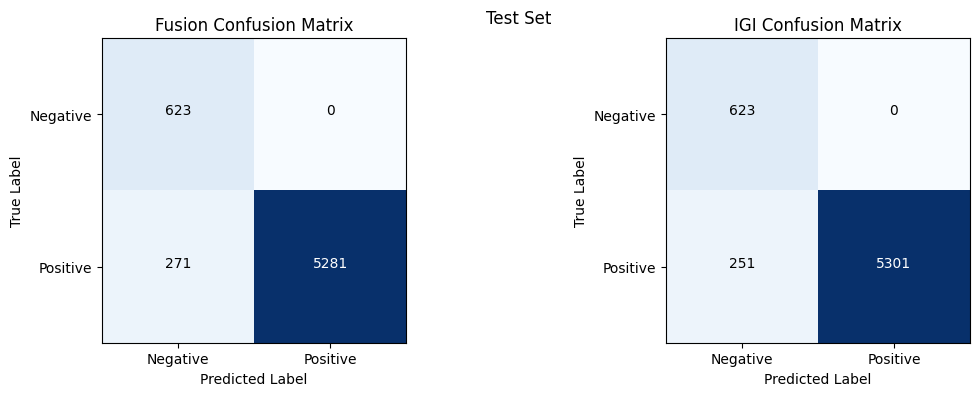

In [177]:
matched_preds = 1*(test_pred_df.outputs >= matched_thres)
# Calculate the confusion matrix
cm1 = confusion_matrix(test_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Fusion Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
fig.suptitle('Test Set')
plt.show()


In [178]:
print('Fusion Model confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.fusion_matched_pred)))
print('IGI confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.encoded_igi_call)))

Fusion Model confusion matrix
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       623
           1       1.00      0.95      0.97      5552

    accuracy                           0.96      6175
   macro avg       0.85      0.98      0.90      6175
weighted avg       0.97      0.96      0.96      6175

IGI confusion matrix
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       623
           1       1.00      0.95      0.98      5552

    accuracy                           0.96      6175
   macro avg       0.86      0.98      0.90      6175
weighted avg       0.97      0.96      0.96      6175



In [179]:
test_pred_df.loc[:,['fusion_matched_pred']] = matched_preds
diff_df = test_pred_df.loc[test_pred_df.encoded_igi_call != test_pred_df.fusion_matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 130


,curve_idx,groundtruth_label,encoded_igi_call,outputs,fusion_matched_pred
390,103226,1,1,0.200872,0.0
393,103250,1,1,0.870363,0.0
441,4922,1,1,0.849241,0.0
592,25474,1,1,0.841537,0.0
602,45628,1,1,0.906601,0.0


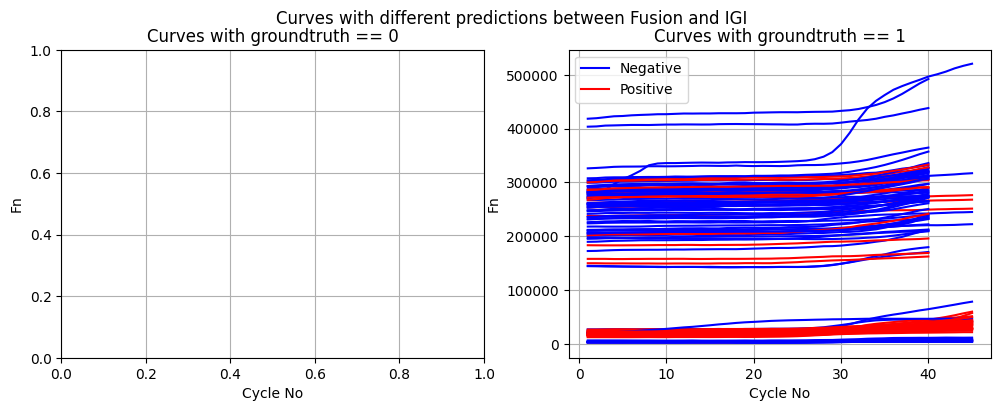

In [183]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['fusion_matched_pred'].values == 0:
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['fusion_matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
fig.suptitle('Curves with different predictions between Fusion and IGI')
plt.legend()
plt.show()

/tmp/ipykernel_2033225/875254701.py:28: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, label='Fusion Scores')


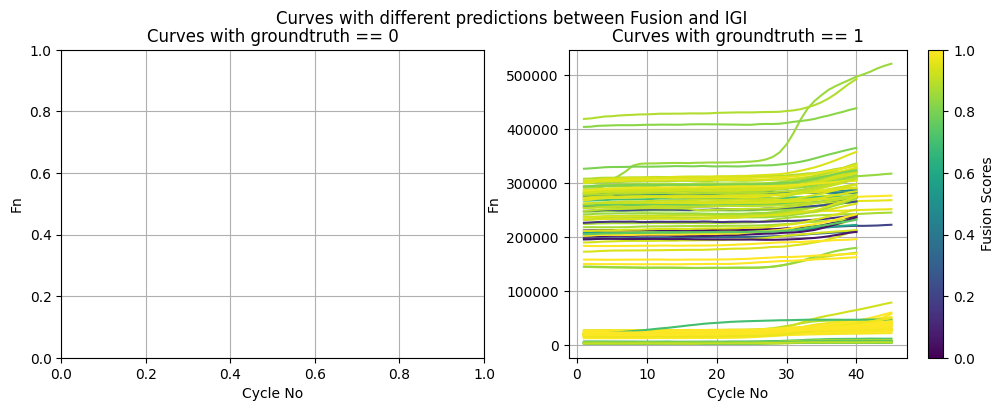

In [181]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1, label = 'Fusion predicts negative')
    else:
        axes[1].plot(x,y, color = color1, label = 'Fusion predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Fusion Scores')
fig.suptitle('Curves with different predictions between Fusion and IGI')
plt.show()

In [182]:
test_sample_df = (test_pred_df[['curve_idx','encoded_igi_call','fusion_matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

test_sample_df.loc[:,'sample_type'] = test_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
test_sample_pred = (test_sample_df
 .groupby('sample_id')[['fusion_matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in fusion prediction is: ', (sum(test_sample_pred.fusion_matched_pred.isin([0,1]))/test_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(test_sample_pred.encoded_igi_call.isin([0,1]))/test_sample_pred.shape[0]))

Agreement rate between genes in fusion prediction is:  0.9794520547945206
Agreement rate between genes in IGI prediction is:  0.9897260273972602


### Other genes validation

Agreement rate between genes in fusion prediction is:  0.9767441860465116
Agreement rate between genes in IGI prediction is:  0.986046511627907
